## Chapter38: Introducing Scikit-Learn

---
* Author:  [Yuttapong Mahasittiwat](mailto:khala1391@gmail.com)
* Technologist | Data Modeler | Data Analyst
* [YouTube](https://www.youtube.com/khala1391)
* [LinkedIn](https://www.linkedin.com/in/yuttapong-m/)
---

Source: [**Python Data Science Handbook** by **VanderPlas**](https://jakevdp.github.io/PythonDataScienceHandbook/)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("numpy version :",np.__version__)
print("pandas version :",pd.__version__)

numpy version : 1.26.4
pandas version : 2.2.3


### Data Representation in Scikit-Learn

In [2]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


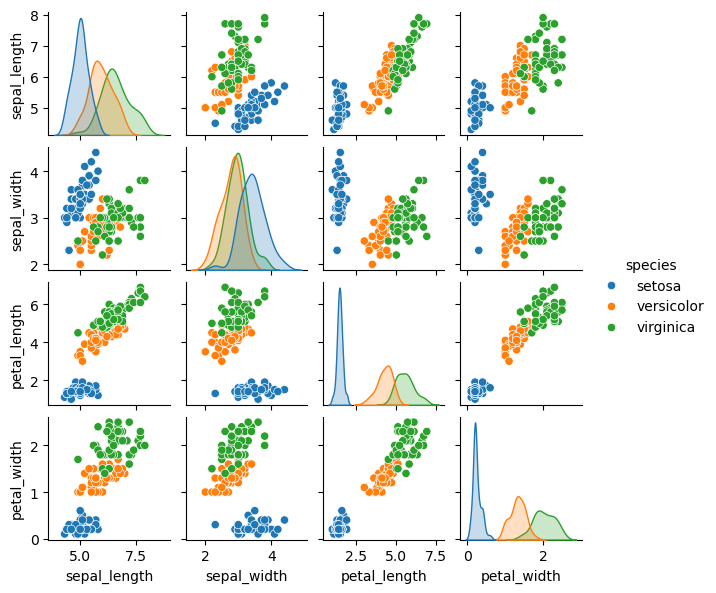

In [3]:
sns.pairplot(data=iris, hue='species', height=1.5)

In [4]:
X_iris =iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [5]:
y_iris = iris['species']
y_iris.shape

(150,)

### The Estimator API

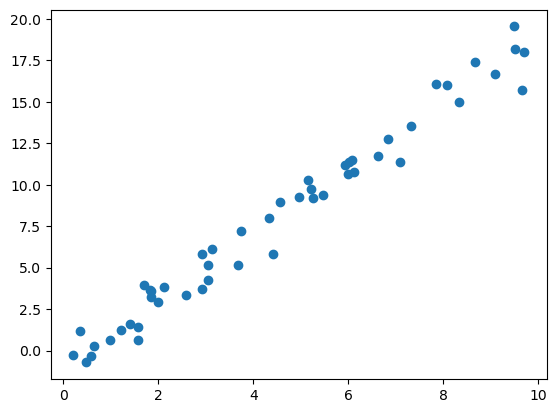

In [6]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(50)
y = 2*x-1 + rng.randn(50)
plt.scatter(x,y)

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

LinearRegression()

In [8]:
X = x[:, np.newaxis]
X.shape

(50, 1)

In [9]:
model.fit(X,y)

LinearRegression()

In [10]:
model.coef_, model.intercept_

(array([1.9776566]), -0.9033107255311164)

In [11]:
xfit =  np.linspace(-1,11)
Xfit = xfit[:, np.newaxis]
yfit = model.predict(Xfit)

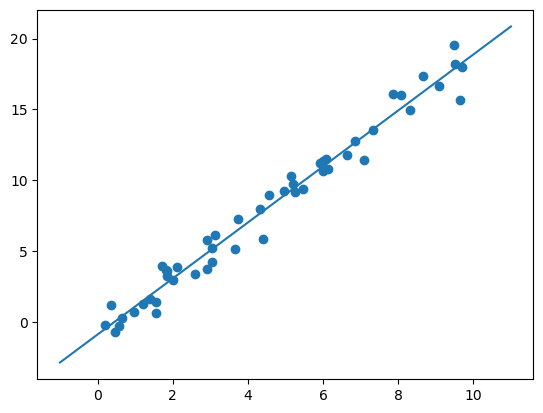

In [12]:
plt.scatter(x,y)
plt.plot(Xfit, yfit)

#### iris classification

In [13]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, y_iris, random_state=1)

In [14]:
from sklearn.naive_bayes import GaussianNB
model =GaussianNB()
model.fit(Xtrain, ytrain)
y_model =model.predict(Xtest)

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,y_model)

0.9736842105263158

#### Iris Dimensionality

In [16]:
from sklearn.decomposition import PCA
model = PCA(n_components=2)
model.fit(X_iris)
X_2d = model.transform(X_iris)

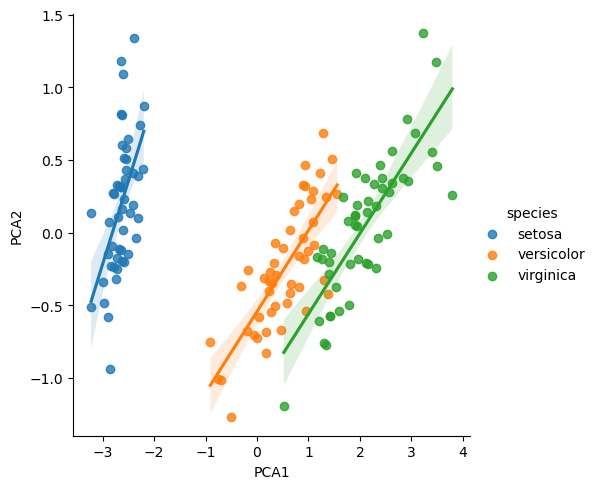

In [17]:
iris['PCA1'] = X_2d[:,0]
iris['PCA2'] = X_2d[:,1]
sns.lmplot(x="PCA1", y="PCA2", hue='species', data=iris, fit_reg=True)

#### Iris Clustering

In [18]:
from sklearn.mixture import GaussianMixture

In [19]:
model = GaussianMixture(n_components=3,
                        covariance_type='full')
model.fit(X_iris)
y_gmm = model.predict(X_iris)

c:\Users\khala\anaconda3\envs\base4ps\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


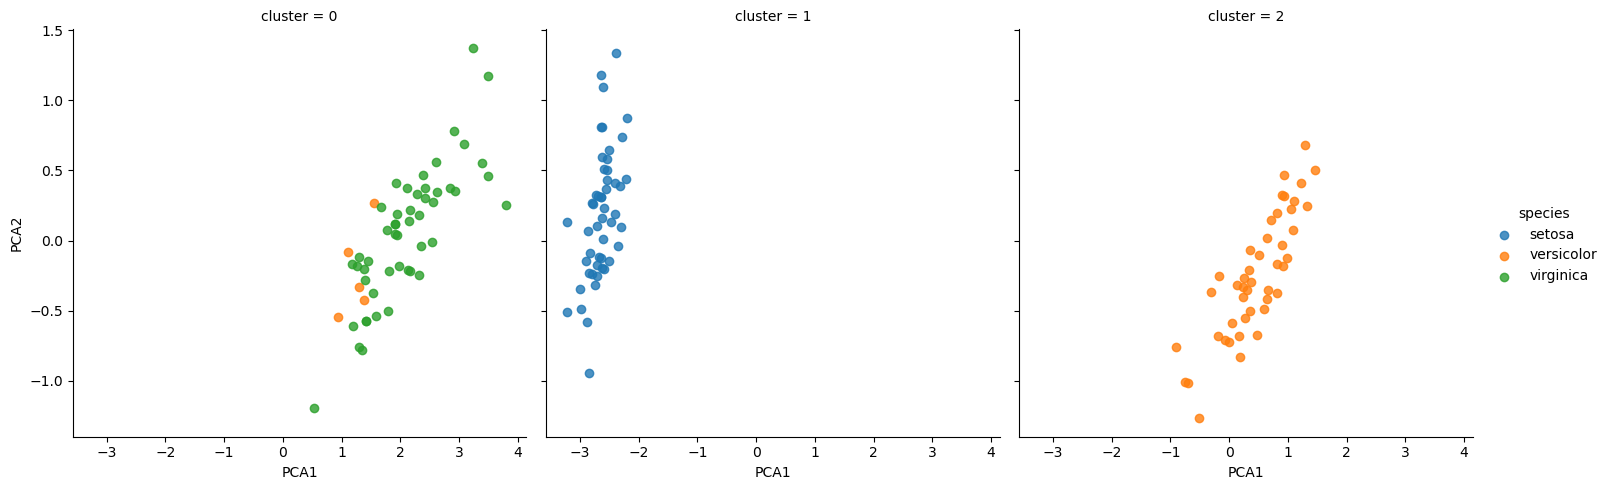

In [20]:
iris['cluster']=y_gmm
sns.lmplot(x="PCA1",y="PCA2", data=iris, hue='species',
            col='cluster', fit_reg=False)

### Application: Exploring Handwritten Digits

In [21]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

(1797, 8, 8)

In [22]:
import matplotlib.pyplot as plt

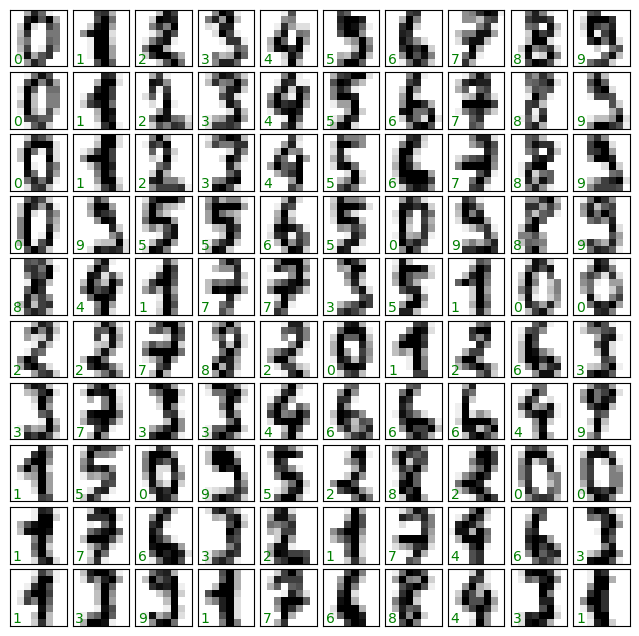

In [25]:
fig, axes =  plt.subplots(10,10, figsize=(8,8),
                          subplot_kw ={'xticks':[], 'yticks':[]},
                          gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap ='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

In [26]:
X =digits.data
X.shape

(1797, 64)

In [27]:
y = digits.target
y.shape

(1797,)

#### Dimensionality Reduction

In [28]:
from sklearn.manifold import Isomap
iso = Isomap(n_components=2)
iso.fit(digits.data)
data_projected = iso.transform(digits.data)
print(data_projected.shape)

c:\Users\khala\anaconda3\envs\base4ps\Lib\site-packages\sklearn\manifold\_isomap.py:359: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\khala\anaconda3\envs\base4ps\Lib\site-packages\scipy\sparse\_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)


C:\Users\khala\AppData\Local\Temp\ipykernel_18108\14844661.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis', 10))


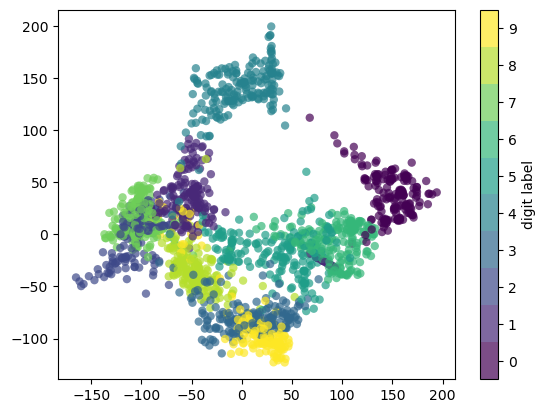

In [35]:
plt.scatter(data_projected[:,0], data_projected[:,1], c=digits.target,
            edgecolors='none', alpha=0.7,
            cmap=plt.cm.get_cmap('viridis', 10))
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-.5,9.5)

In [36]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X,y, random_state=0)

In [38]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(Xtrain,ytrain)
y_model= model.predict(Xtest)

In [41]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, y_model)

0.8333333333333334

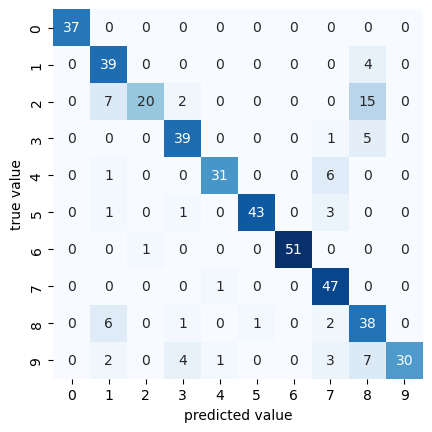

In [44]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, y_model)
sns.heatmap(mat,square=True, annot=True, cbar=False, cmap='Blues')
plt.xlabel('predicted value')
plt.ylabel('true value');

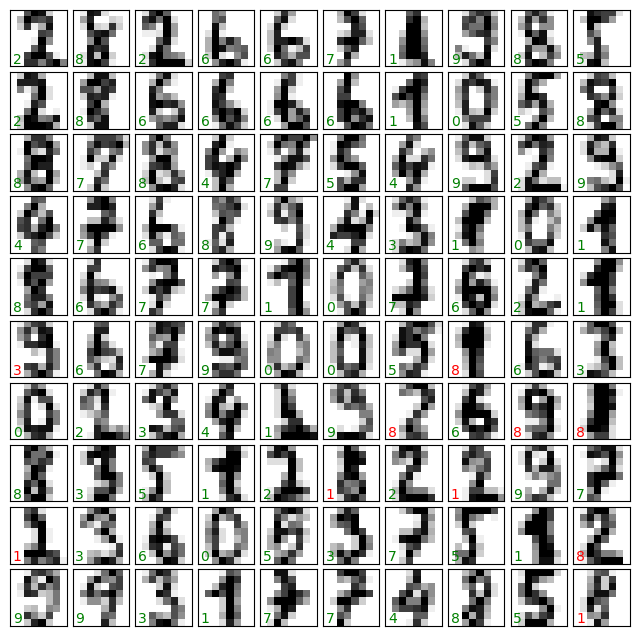

In [46]:
fig, axes =  plt.subplots(10,10, figsize=(8,8),
                          subplot_kw ={'xticks':[], 'yticks':[]},
                          gridspec_kw=dict(hspace=0.1, wspace=0.1))
test_images = Xtest.reshape(-1,8,8)
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap ='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(y_model[i]),
            transform=ax.transAxes, 
            color='green' if  (ytest[i]== y_model[i]) else 'red')